# QUBO Portfolio Optimization Results Analysis - Wide Dataset

This notebook loads and analyzes QUBO portfolio optimization results for the **Wide Dataset**, providing comprehensive comparisons across different solvers and weight distribution analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
import glob
import os
from pathlib import Path
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

# Configure matplotlib for better display
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 11

# Create artifacts directory for saving plots
artifacts_dir = '../../artifacts'
os.makedirs(artifacts_dir, exist_ok=True)
print(f"Artifacts directory: {artifacts_dir}")

Artifacts directory: ../../artifacts


## Data Loading Functions

In [2]:
def load_pickle_result(file_path):
    """Load a single pickle result file."""
    try:
        with open(file_path, 'rb') as f:
            return pickle.load(f)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def parse_filename(filename):
    """Parse QUBO optimization result filename to extract metadata."""
    # Handle multiple filename formats:
    # Format 1: results_{solver}_{period}.pkl (e.g., results_bf_0.pkl)
    # Format 2: results_{dataset}_{solver}_{period}.pkl (e.g., results_synth_ew_0.pkl)
    # Format 3: results_{solver_with_underscore}_{period}.pkl (e.g., results_dwave_cqm_0.pkl)
    
    basename = os.path.basename(filename)
    parts = basename.replace('.pkl', '').replace('results_', '').split('_')
    
    # Try to find the period (last part should be a number)
    period = None
    period_idx = None
    
    for i in range(len(parts) - 1, -1, -1):
        try:
            period = int(parts[i])
            period_idx = i
            break
        except ValueError:
            continue
    
    if period is None:
        return None, None, None
    
    # Everything before period is either dataset_solver or just solver
    prefix_parts = parts[:period_idx]
    
    if len(prefix_parts) == 0:
        return None, None, None
    
    # Determine dataset and solver
    # Common single-word solvers
    known_solvers = {'ew', 'ga', 'bf', 'hrp'}
    known_multi_word_solvers = {'dwave_cqm', 'dwave_nl'}
    
    # Check if first part is a known solver
    if prefix_parts[0] in known_solvers:
        # Format 1: results_{solver}_{period}.pkl
        dataset = 'wide'  # Assume wide dataset for files without explicit dataset name
        solver = prefix_parts[0]
    elif len(prefix_parts) >= 2:
        # Check for multi-word solvers like dwave_cqm
        potential_solver = '_'.join(prefix_parts)
        if potential_solver in known_multi_word_solvers:
            # Format 3: results_{multi_word_solver}_{period}.pkl
            dataset = 'wide'
            solver = potential_solver
        elif prefix_parts[-1] in known_solvers:
            # Format 2: results_{dataset}_{solver}_{period}.pkl
            dataset = '_'.join(prefix_parts[:-1])
            solver = prefix_parts[-1]
        elif len(prefix_parts) >= 3 and '_'.join(prefix_parts[-2:]) in known_multi_word_solvers:
            # Format 2 with multi-word solver: results_{dataset}_{multi_word_solver}_{period}.pkl
            dataset = '_'.join(prefix_parts[:-2])
            solver = '_'.join(prefix_parts[-2:])
        else:
            # Assume it's dataset_solver format with unknown solver
            dataset = '_'.join(prefix_parts[:-1])
            solver = prefix_parts[-1]
    else:
        # Single-word prefix that's not a known solver
        dataset = 'wide'
        solver = prefix_parts[0]
    
    return dataset, period, solver

def load_all_results(results_dir='../../results/qubo'):
    """Load all QUBO optimization results from the directory."""
    results = []
    
    # Find all pickle files
    pickle_files = glob.glob(os.path.join(results_dir, '*.pkl'))
    
    print(f"Found {len(pickle_files)} result files")
    
    for file_path in pickle_files:
        # Parse filename
        dataset, period, solver = parse_filename(file_path)
        
        if dataset is not None:
            # Load data
            data = load_pickle_result(file_path)
            
            if data is not None:
                # Extract key metrics
                portfolio_returns = data.get('portfolio_cumulative_returns', [])
                benchmark_returns = data.get('benchmark_cumulative_returns', [])
                execution_time = data.get('total_run_time', 0)
                start_date = data.get('start_date')
                end_date = data.get('end_date')
                
                # Calculate final return if available
                final_return = None
                if portfolio_returns is not None:
                    try:
                        if hasattr(portfolio_returns, '__len__') and len(portfolio_returns) > 0:
                            final_return = portfolio_returns[-1]
                    except:
                        pass
                
                # Calculate benchmark final return
                benchmark_final = None
                if benchmark_returns is not None:
                    try:
                        if hasattr(benchmark_returns, '__len__') and len(benchmark_returns) > 0:
                            benchmark_final = benchmark_returns[-1]
                    except:
                        pass
                
                results.append({
                    'filename': os.path.basename(file_path),
                    'dataset': dataset,
                    'period': period,
                    'solver': solver,
                    'portfolio_returns': portfolio_returns,
                    'benchmark_returns': benchmark_returns,
                    'final_return': final_return,
                    'benchmark_final': benchmark_final,
                    'execution_time': execution_time,
                    'start_date': start_date,
                    'end_date': end_date,
                    'data': data
                })
    
    return results

# Load all results
print("Loading all QUBO optimization results...")
all_results = load_all_results()
print(f"Loaded {len(all_results)} successful results")

Loading all QUBO optimization results...
Found 68 result files
Loaded 68 successful results


In [3]:
# Create summary DataFrame and filter for wide dataset only
df_results = pd.DataFrame(all_results)

# Filter for wide dataset only
df_results = df_results[df_results['dataset'] == 'wide'].copy()

# Display overview
print("=" * 80)
print("QUBO PORTFOLIO OPTIMIZATION RESULTS - WIDE DATASET")
print("=" * 80)

print(f"\nTotal results loaded: {len(df_results)}")
print(f"Solvers: {sorted(df_results['solver'].unique())}")
print(f"Periods: {sorted(df_results['period'].unique())}")

# Summary by solver
print("\nResults count by solver:")
print(df_results['solver'].value_counts().sort_index())

# Map solver codes to readable names
solver_names = {
    'ew': 'Equal Weights',
    'ga': 'Genetic Algorithm',
    'bf': 'Scipy SLSQP',
    'hrp': 'Riskfolio QUBO',
    'dwave_cqm': 'D-Wave CQM',
    'dwave_nl': 'D-Wave Nonlinear'
}

df_results['solver_name'] = df_results['solver'].map(lambda x: solver_names.get(x, x))
df_results['dataset_name'] = 'Wide Dataset'

# Create df_wide alias for compatibility with existing code
df_wide = df_results.copy()

QUBO PORTFOLIO OPTIMIZATION RESULTS - WIDE DATASET

Total results loaded: 48
Solvers: ['bf', 'dwave_cqm', 'ew', 'ga', 'hrp']
Periods: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Results count by solver:
solver
bf           10
dwave_cqm     8
ew           10
ga           10
hrp          10
Name: count, dtype: int64


CUMULATIVE RETURNS TRACES - ALL PERIODS COMPARISON

Plotting 10 periods with 5 solvers
Saved: qubo_cumulative_returns_all_periods.png


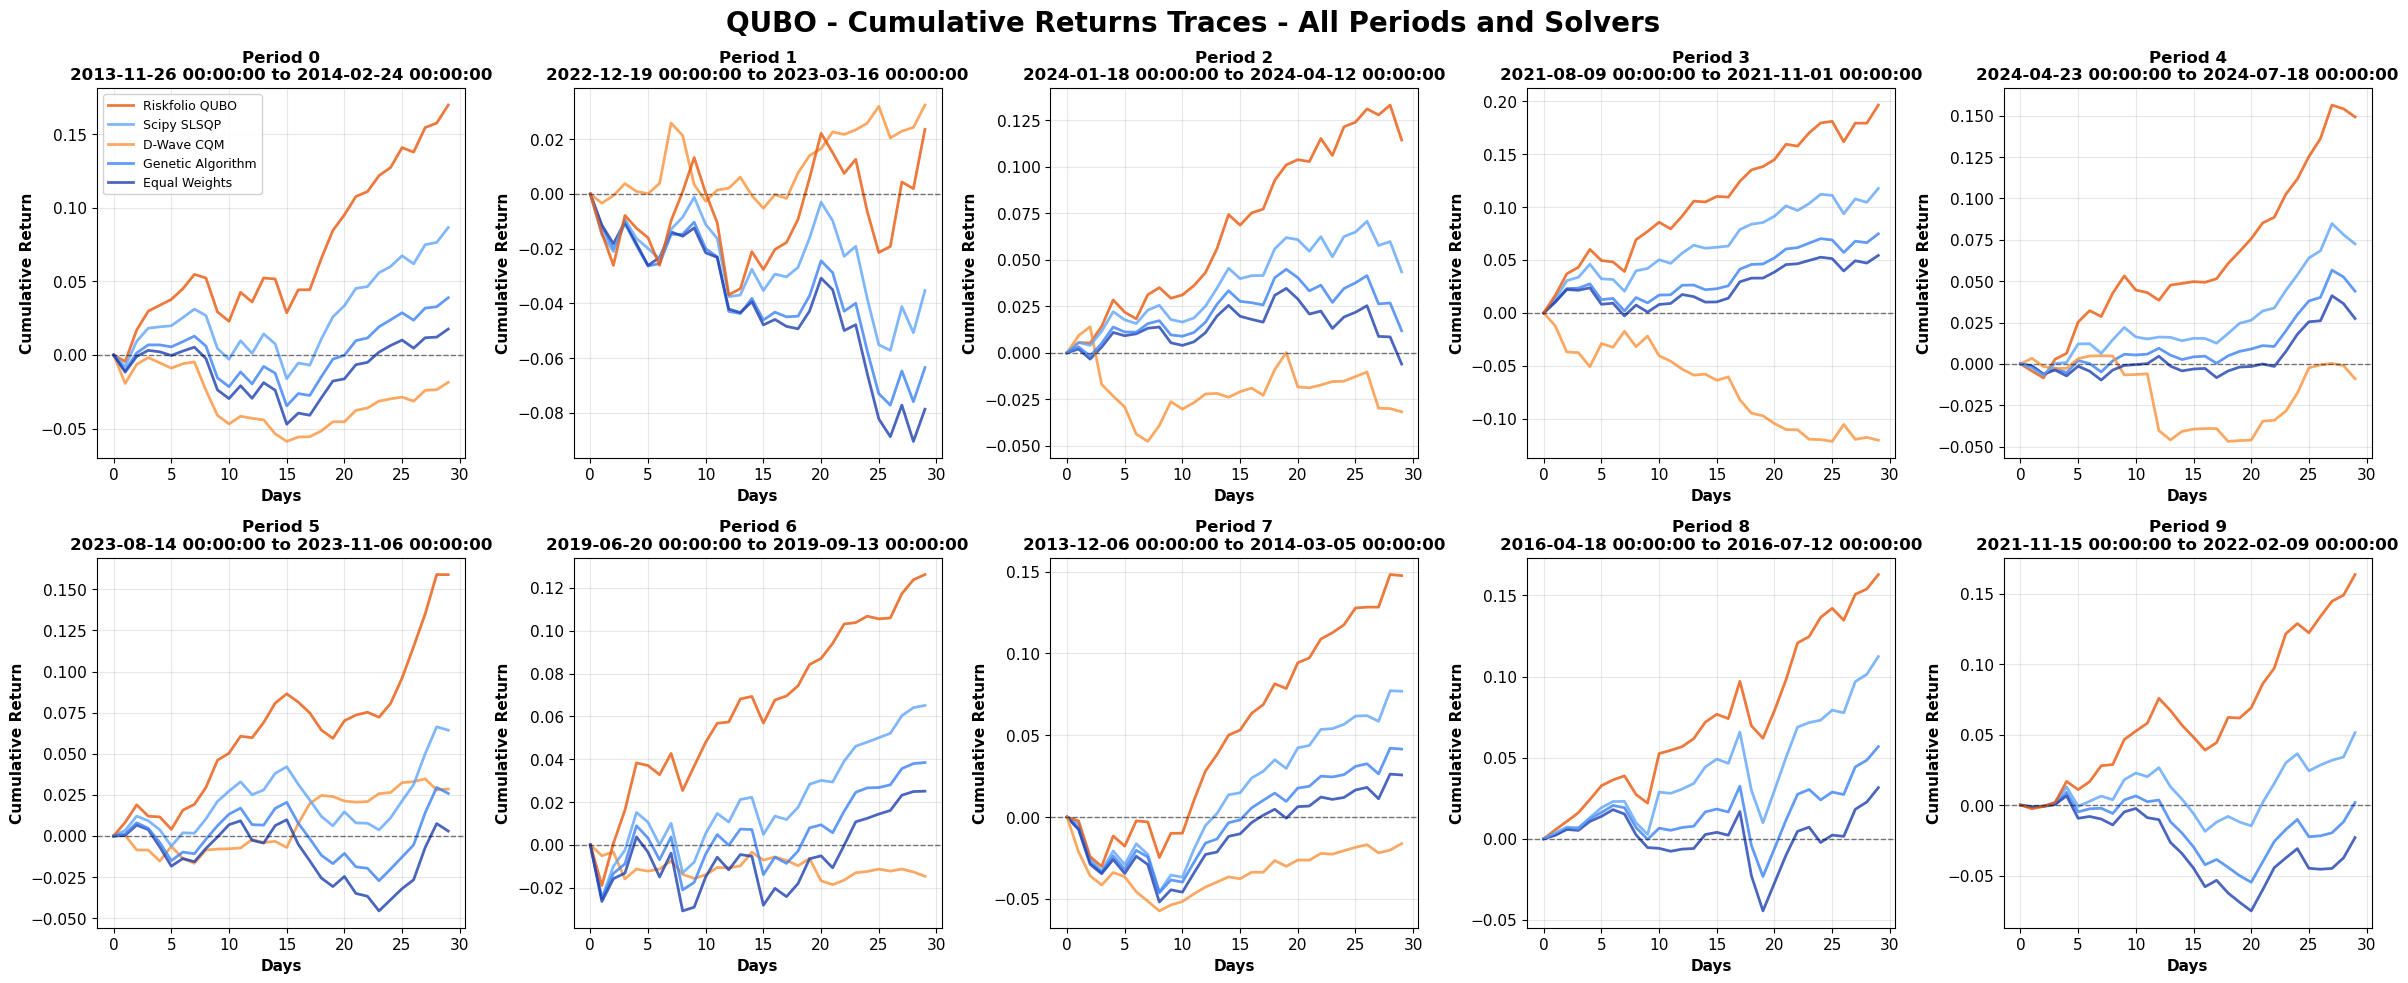


PERIOD-BY-PERIOD SUMMARY

Period 0:
--------------------------------------------------
  Riskfolio QUBO      : Return =   0.1698 ( 16.98%), Time =   51.71s
  Scipy SLSQP         : Return =   0.0866 (  8.66%), Time = 3343.62s
  Genetic Algorithm   : Return =   0.0389 (  3.89%), Time = 4346.44s
  Equal Weights       : Return =   0.0176 (  1.76%), Time =    0.13s
  D-Wave CQM          : Return =  -0.0186 ( -1.86%), Time = 9518.25s
  ✓ Best: Riskfolio QUBO (0.1698)

Period 1:
--------------------------------------------------
  D-Wave CQM          : Return =   0.0325 (  3.25%), Time = 8257.90s
  Riskfolio QUBO      : Return =   0.0236 (  2.36%), Time =  250.27s
  Scipy SLSQP         : Return =  -0.0353 ( -3.53%), Time = 3264.43s
  Genetic Algorithm   : Return =  -0.0634 ( -6.34%), Time = 4342.46s
  Equal Weights       : Return =  -0.0786 ( -7.86%), Time =    0.11s
  ✓ Best: D-Wave CQM (0.0325)

Period 2:
--------------------------------------------------
  Riskfolio QUBO      : Return =  

In [4]:
# Plot cumulative returns traces for all periods comparing all solvers
print("=" * 100)
print("CUMULATIVE RETURNS TRACES - ALL PERIODS COMPARISON")
print("=" * 100)

# Get unique periods and solvers
periods = sorted(df_wide['period'].unique())
solvers = sorted(df_wide['solver_name'].unique())

print(f"\nPlotting {len(periods)} periods with {len(solvers)} solvers")

# Define colors for each solver (consistent across all plots)
solver_colors = {
    'Equal Weights': '#1E40AF',      # Deep blue
    'Genetic Algorithm': '#3B82F6',  # Medium blue
    'Scipy SLSQP': '#60A5FA',        # Light blue
    'Riskfolio QUBO': '#EA580C',     # Deep orange
    'D-Wave CQM': '#FB923C',         # Light orange
    'D-Wave Nonlinear': '#FBBF24'    # Yellow-orange
}

# Create subplots - 2 rows x 5 columns for 10 periods
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
fig.suptitle('QUBO - Cumulative Returns Traces - All Periods and Solvers', fontsize=20, fontweight='bold')
axes = axes.flatten()

for idx, period in enumerate(periods):
    ax = axes[idx]
    
    # Get data for this period
    period_data = df_wide[df_wide['period'] == period]
    
    # Plot each solver's trace
    for _, row in period_data.iterrows():
        solver_name = row['solver_name']
        portfolio_returns = row['portfolio_returns']
        start_date = row['start_date']
        end_date = row['end_date']
        
        if portfolio_returns is not None and hasattr(portfolio_returns, '__len__'):
            returns_array = np.array(portfolio_returns)
            if len(returns_array) > 0:
                # Create time axis
                time_axis = np.arange(len(returns_array))
                
                # Plot the trace
                color = solver_colors.get(solver_name, '#000000')
                ax.plot(time_axis, returns_array, 
                       label=solver_name, 
                       color=color, 
                       linewidth=2, 
                       alpha=0.8)
    
    # Format the subplot
    ax.set_title(f'Period {period}\n{start_date} to {end_date}', 
                fontweight='bold', fontsize=12)
    ax.set_xlabel('Days', fontweight='bold')
    ax.set_ylabel('Cumulative Return', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    # Add legend only to first subplot
    if idx == 0:
        ax.legend(loc='best', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(artifacts_dir, 'qubo_cumulative_returns_all_periods.png'), dpi=300, bbox_inches='tight')
print("Saved: qubo_cumulative_returns_all_periods.png")
plt.show()

# Print summary statistics for each period
print("\n" + "=" * 100)
print("PERIOD-BY-PERIOD SUMMARY")
print("=" * 100)

for period in periods:
    period_data = df_wide[df_wide['period'] == period]
    valid_data = period_data[period_data['final_return'].notna()]
    
    if len(valid_data) > 0:
        print(f"\nPeriod {period}:")
        print("-" * 50)
        
        # Sort by final return
        sorted_data = valid_data.sort_values('final_return', ascending=False)
        
        for _, row in sorted_data.iterrows():
            solver_name = row['solver_name']
            final_return = row['final_return']
            exec_time = row['execution_time']
            print(f"  {solver_name:20s}: Return = {final_return:>8.4f} ({final_return*100:>6.2f}%), Time = {exec_time:>7.2f}s")
        
        best = sorted_data.iloc[0]
        print(f"  ✓ Best: {best['solver_name']} ({best['final_return']:.4f})")


AVERAGE PERFORMANCE ACROSS ALL PERIODS

Solver Performance Summary:
----------------------------------------------------------------------------------------------------
           Solver  Avg_Return  Std_Return    Avg_Time    Std_Time  N_Periods
       D-Wave CQM   -0.018683    0.046994 8094.801719 1758.858207          8
    Equal Weights    0.007686    0.037216    0.113239    0.011958         10
Genetic Algorithm    0.027042    0.037986 4339.740502    3.092143         10
   Riskfolio QUBO    0.141234    0.047171  110.119655   90.987858         10
      Scipy SLSQP    0.065482    0.042663 3400.318830  104.423568         10
Saved: qubo_average_performance.png


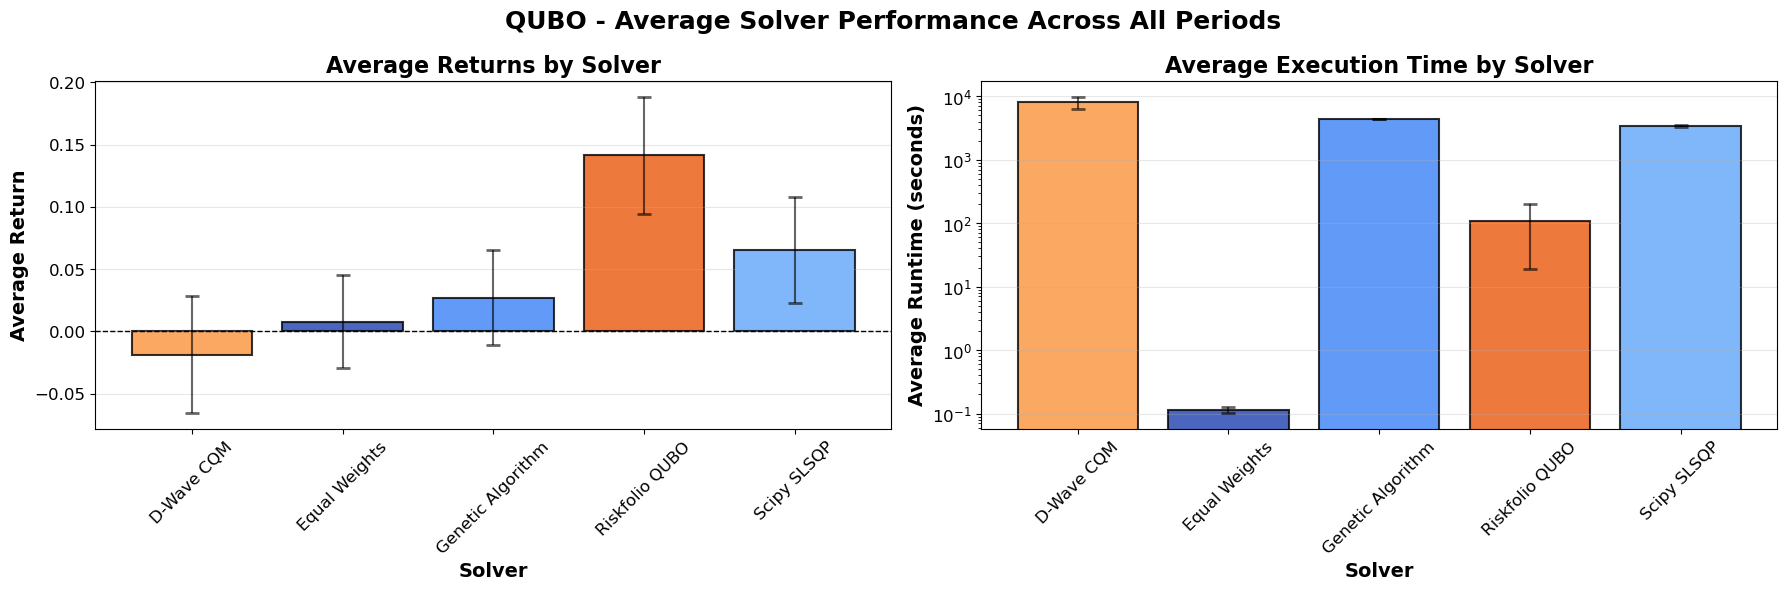


KEY INSIGHTS

Best Average Return: Riskfolio QUBO (0.1412 ± 0.0472)
Worst Average Return: D-Wave CQM (-0.0187 ± 0.0470)
Fastest Solver: Equal Weights (0.11s ± 0.01s)
Slowest Solver: D-Wave CQM (8094.80s ± 1758.86s)
Most Consistent: Equal Weights (Std Dev: 0.0372)

Best Return/Time Efficiency: Equal Weights (0.067875 return/sec)


In [5]:
# Average Performance Analysis - Returns and Runtime
print("\n" + "=" * 100)
print("AVERAGE PERFORMANCE ACROSS ALL PERIODS")
print("=" * 100)

# Calculate average statistics per solver
solver_stats = []

for solver_name in sorted(df_wide['solver_name'].unique()):
    solver_data = df_wide[df_wide['solver_name'] == solver_name]
    valid_data = solver_data[solver_data['final_return'].notna()]
    
    if len(valid_data) > 0:
        avg_return = valid_data['final_return'].mean()
        std_return = valid_data['final_return'].std()
        avg_time = valid_data['execution_time'].mean()
        std_time = valid_data['execution_time'].std()
        n_periods = len(valid_data)
        
        solver_stats.append({
            'Solver': solver_name,
            'Avg_Return': avg_return,
            'Std_Return': std_return,
            'Avg_Time': avg_time,
            'Std_Time': std_time,
            'N_Periods': n_periods
        })

df_stats = pd.DataFrame(solver_stats)

# Print summary table
print("\nSolver Performance Summary:")
print("-" * 100)
print(df_stats.to_string(index=False))

# Create barplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('QUBO - Average Solver Performance Across All Periods', fontsize=18, fontweight='bold')

# Define consistent colors
solver_colors = {
    'Equal Weights': '#1E40AF',      # Deep blue
    'Genetic Algorithm': '#3B82F6',  # Medium blue
    'Scipy SLSQP': '#60A5FA',        # Light blue
    'Riskfolio QUBO': '#EA580C',     # Deep orange
    'D-Wave CQM': '#FB923C',         # Light orange
    'D-Wave Nonlinear': '#FBBF24'    # Yellow-orange
}

# 1. Average Returns Barplot
colors_returns = [solver_colors.get(solver, '#000000') for solver in df_stats['Solver']]
bars1 = ax1.bar(df_stats['Solver'], df_stats['Avg_Return'], 
               color=colors_returns, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add error bars for standard deviation
ax1.errorbar(df_stats['Solver'], df_stats['Avg_Return'], 
            yerr=df_stats['Std_Return'], 
            fmt='none', ecolor='black', capsize=5, capthick=2, alpha=0.6)

ax1.set_ylabel('Average Return', fontweight='bold', fontsize=14)
ax1.set_xlabel('Solver', fontweight='bold', fontsize=14)
ax1.set_title('Average Returns by Solver', fontweight='bold', fontsize=16)
ax1.tick_params(axis='x', rotation=45, labelsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax1.grid(True, alpha=0.3, axis='y')
ax1.axhline(y=0, color='black', linestyle='--', linewidth=1)

# 2. Average Runtime Barplot
colors_time = [solver_colors.get(solver, '#000000') for solver in df_stats['Solver']]
bars2 = ax2.bar(df_stats['Solver'], df_stats['Avg_Time'], 
               color=colors_time, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add error bars for standard deviation
ax2.errorbar(df_stats['Solver'], df_stats['Avg_Time'], 
            yerr=df_stats['Std_Time'], 
            fmt='none', ecolor='black', capsize=5, capthick=2, alpha=0.6)

ax2.set_ylabel('Average Runtime (seconds)', fontweight='bold', fontsize=14)
ax2.set_xlabel('Solver', fontweight='bold', fontsize=14)
ax2.set_title('Average Execution Time by Solver', fontweight='bold', fontsize=16)
ax2.tick_params(axis='x', rotation=45, labelsize=12)
ax2.tick_params(axis='y', labelsize=12)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_yscale('log')  # Log scale for better visualization if times vary widely

plt.tight_layout()
plt.savefig(os.path.join(artifacts_dir, 'qubo_average_performance.png'), dpi=300, bbox_inches='tight')
print("Saved: qubo_average_performance.png")
plt.show()

# Print key insights
print("\n" + "=" * 100)
print("KEY INSIGHTS")
print("=" * 100)

best_return = df_stats.loc[df_stats['Avg_Return'].idxmax()]
worst_return = df_stats.loc[df_stats['Avg_Return'].idxmin()]
fastest = df_stats.loc[df_stats['Avg_Time'].idxmin()]
slowest = df_stats.loc[df_stats['Avg_Time'].idxmax()]
most_consistent = df_stats.loc[df_stats['Std_Return'].idxmin()]

print(f"\nBest Average Return: {best_return['Solver']} ({best_return['Avg_Return']:.4f} ± {best_return['Std_Return']:.4f})")
print(f"Worst Average Return: {worst_return['Solver']} ({worst_return['Avg_Return']:.4f} ± {worst_return['Std_Return']:.4f})")
print(f"Fastest Solver: {fastest['Solver']} ({fastest['Avg_Time']:.2f}s ± {fastest['Std_Time']:.2f}s)")
print(f"Slowest Solver: {slowest['Solver']} ({slowest['Avg_Time']:.2f}s ± {slowest['Std_Time']:.2f}s)")
print(f"Most Consistent: {most_consistent['Solver']} (Std Dev: {most_consistent['Std_Return']:.4f})")

# Calculate performance-to-time ratio (return per second)
df_stats['Return_Per_Second'] = df_stats['Avg_Return'] / df_stats['Avg_Time']
best_efficiency = df_stats.loc[df_stats['Return_Per_Second'].idxmax()]
print(f"\nBest Return/Time Efficiency: {best_efficiency['Solver']} ({best_efficiency['Return_Per_Second']:.6f} return/sec)")

In [6]:
def extract_weights_from_results(df_subset):
    """Extract portfolio weights from all results in a dataset subset."""
    weights_by_solver = {}
    
    for _, result in df_subset.iterrows():
        solver_name = result['solver_name']
        data = result['data']
        
        if data is not None:
            # Try different possible keys for weights
            weights = None
            
            # Check for weights_history first (most likely location)
            if 'weights_history' in data and data['weights_history'] is not None:
                weights_hist = data['weights_history']
                
                # weights_history might be a list of weight arrays or a single array
                if isinstance(weights_hist, (list, tuple)) and len(weights_hist) > 0:
                    # Take the final weights (last entry)
                    weights = np.array(weights_hist[-1])
                elif hasattr(weights_hist, 'shape') or hasattr(weights_hist, '__len__'):
                    # It's already a weights array
                    weights = np.array(weights_hist)
            
            # Fallback to other possible keys
            if weights is None:
                possible_weight_keys = [
                    'portfolio_weights',
                    'weights', 
                    'optimal_weights',
                    'final_weights',
                    'solution_weights'
                ]
                
                for key in possible_weight_keys:
                    if key in data and data[key] is not None:
                        weights = np.array(data[key])
                        break
            
            if weights is not None:
                # Ensure weights is 1D
                if weights.ndim > 1:
                    weights = weights.flatten()
                
                # Filter out zero or very small weights
                non_zero_weights = weights[weights > 1e-6]
                
                if len(non_zero_weights) > 0:
                    if solver_name not in weights_by_solver:
                        weights_by_solver[solver_name] = []
                    weights_by_solver[solver_name].extend(non_zero_weights.tolist())
                    
                    # Debug: print info for first result per solver
                    if len(weights_by_solver[solver_name]) == len(non_zero_weights):
                        print(f"Found weights for {solver_name}: {len(non_zero_weights)} positions, sum={np.sum(non_zero_weights):.6f}")
    
    return weights_by_solver

def plot_weight_distribution_histograms(df_subset, dataset_name, bins=None):
    """Plot weight distribution histograms for all solvers in a dataset."""
    
    weights_by_solver = extract_weights_from_results(df_subset)
    
    if not weights_by_solver:
        print(f"No weight data found for {dataset_name}")
        return
    
    print(f"\n{dataset_name} - Weight Distribution Analysis:")
    print("=" * 60)
    
    n_solvers = len(weights_by_solver)
    if n_solvers == 0:
        return
    
    # Determine grid size and bins
    if n_solvers <= 4:
        rows, cols = 2, 2
        default_bins = 20
    elif n_solvers <= 6:
        rows, cols = 2, 3
        default_bins = 25
    else:
        rows, cols = 3, 3
        default_bins = 30
    
    if bins is None:
        bins = default_bins
    
    # Create subplots
    fig, axes = plt.subplots(rows, cols, figsize=(18, 12))
    fig.suptitle(f'{dataset_name} - Portfolio Weight Distributions by Solver', 
                 fontsize=18, fontweight='bold')
    
    # Flatten axes array for easy indexing
    if n_solvers == 1:
        axes = [axes]
    elif rows == 1 or cols == 1:
        axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    else:
        axes = axes.flatten()
    
    colors = ['#2E8B57', '#4682B4', '#CD853F', '#DC143C', '#9932CC', '#FF6347', '#8A2BE2', '#00CED1', '#FF1493']
    
    for idx, (solver_name, weights) in enumerate(weights_by_solver.items()):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        weights_array = np.array(weights)
        
        # Plot histogram
        ax.hist(weights_array, bins=bins, alpha=0.7, color=colors[idx % len(colors)], 
                edgecolor='black', density=True)
        
        # Calculate statistics
        mean_weight = np.mean(weights_array)
        std_weight = np.std(weights_array)
        max_weight = np.max(weights_array)
        min_weight = np.min(weights_array)
        median_weight = np.median(weights_array)
        n_positions = len(weights_array)
        
        ax.set_xlabel('Weight', fontweight='bold')
        ax.set_ylabel('Density', fontweight='bold')
        ax.set_title(f'{solver_name}\n({n_positions} positions)', fontweight='bold')
        ax.set_yscale('log')  # Set y-axis to log scale
        ax.grid(True, alpha=0.3)
        
        # Add statistics text box
        stats_text = f'Mean: {mean_weight:.4f}\nStd: {std_weight:.4f}\nMax: {max_weight:.4f}'
        ax.text(0.65, 0.85, stats_text, transform=ax.transAxes, 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9),
                fontsize=11, verticalalignment='top')
        
        # Print detailed statistics
        print(f"\n{solver_name}:")
        print(f"  Total positions: {n_positions}")
        print(f"  Mean weight: {mean_weight:.6f} ({mean_weight*100:.4f}%)")
        print(f"  Std weight: {std_weight:.6f}")
        print(f"  Min weight: {min_weight:.6f}")
        print(f"  Max weight: {max_weight:.6f} ({max_weight*100:.4f}%)")
        print(f"  Median weight: {median_weight:.6f}")
        
        # Concentration metrics
        sorted_weights = np.sort(weights_array)[::-1]
        if len(sorted_weights) >= 5:
            top5_sum = np.sum(sorted_weights[:5])
            print(f"  Top 5 positions: {top5_sum:.4f} ({top5_sum*100:.2f}%)")
        if len(sorted_weights) >= 10:
            top10_sum = np.sum(sorted_weights[:10])
            print(f"  Top 10 positions: {top10_sum:.4f} ({top10_sum*100:.2f}%)")
        if len(sorted_weights) >= 20:
            top20_sum = np.sum(sorted_weights[:20])
            print(f"  Top 20 positions: {top20_sum:.4f} ({top20_sum*100:.2f}%)")
    
    # Hide unused subplots
    for idx in range(len(weights_by_solver), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    
    # Save the figure
    artifacts_dir = '../../artifacts'
    filename = f"{dataset_name.lower().replace(' ', '_').replace('-', '_')}_weight_distributions.png"
    plt.savefig(os.path.join(artifacts_dir, filename), dpi=300, bbox_inches='tight')
    print(f"Saved: {filename}")
    plt.show()
    
    return weights_by_solver

## Wide Dataset - Comprehensive Weight Distribution Analysis

This section provides detailed weight distribution analysis for the wide dataset, examining how different solvers allocate weights across the available assets.


WEIGHT DISTRIBUTION ANALYSIS - WIDE DATASET

Analyzing how different solvers allocate weights across the 680 available assets...
Found weights for Scipy SLSQP: 20400 positions, sum=30.000000
Found weights for Riskfolio QUBO: 2050 positions, sum=29.999984
Found weights for D-Wave CQM: 20400 positions, sum=30.000000
Found weights for Equal Weights: 20400 positions, sum=30.000000
Found weights for Genetic Algorithm: 20400 positions, sum=30.000000

Wide Dataset - QUBO Optimization - Weight Distribution Analysis:

Scipy SLSQP:
  Total positions: 204000
  Mean weight: 0.001471 (0.1471%)
  Std weight: 0.002396
  Min weight: 0.001000
  Max weight: 0.014706 (1.4706%)
  Median weight: 0.001000
  Top 5 positions: 0.0735 (7.35%)
  Top 10 positions: 0.1471 (14.71%)
  Top 20 positions: 0.2941 (29.41%)

Riskfolio QUBO:
  Total positions: 20480
  Mean weight: 0.014648 (1.4648%)
  Std weight: 0.000760
  Min weight: 0.000001
  Max weight: 0.014706 (1.4706%)
  Median weight: 0.014706
  Top 5 positions: 

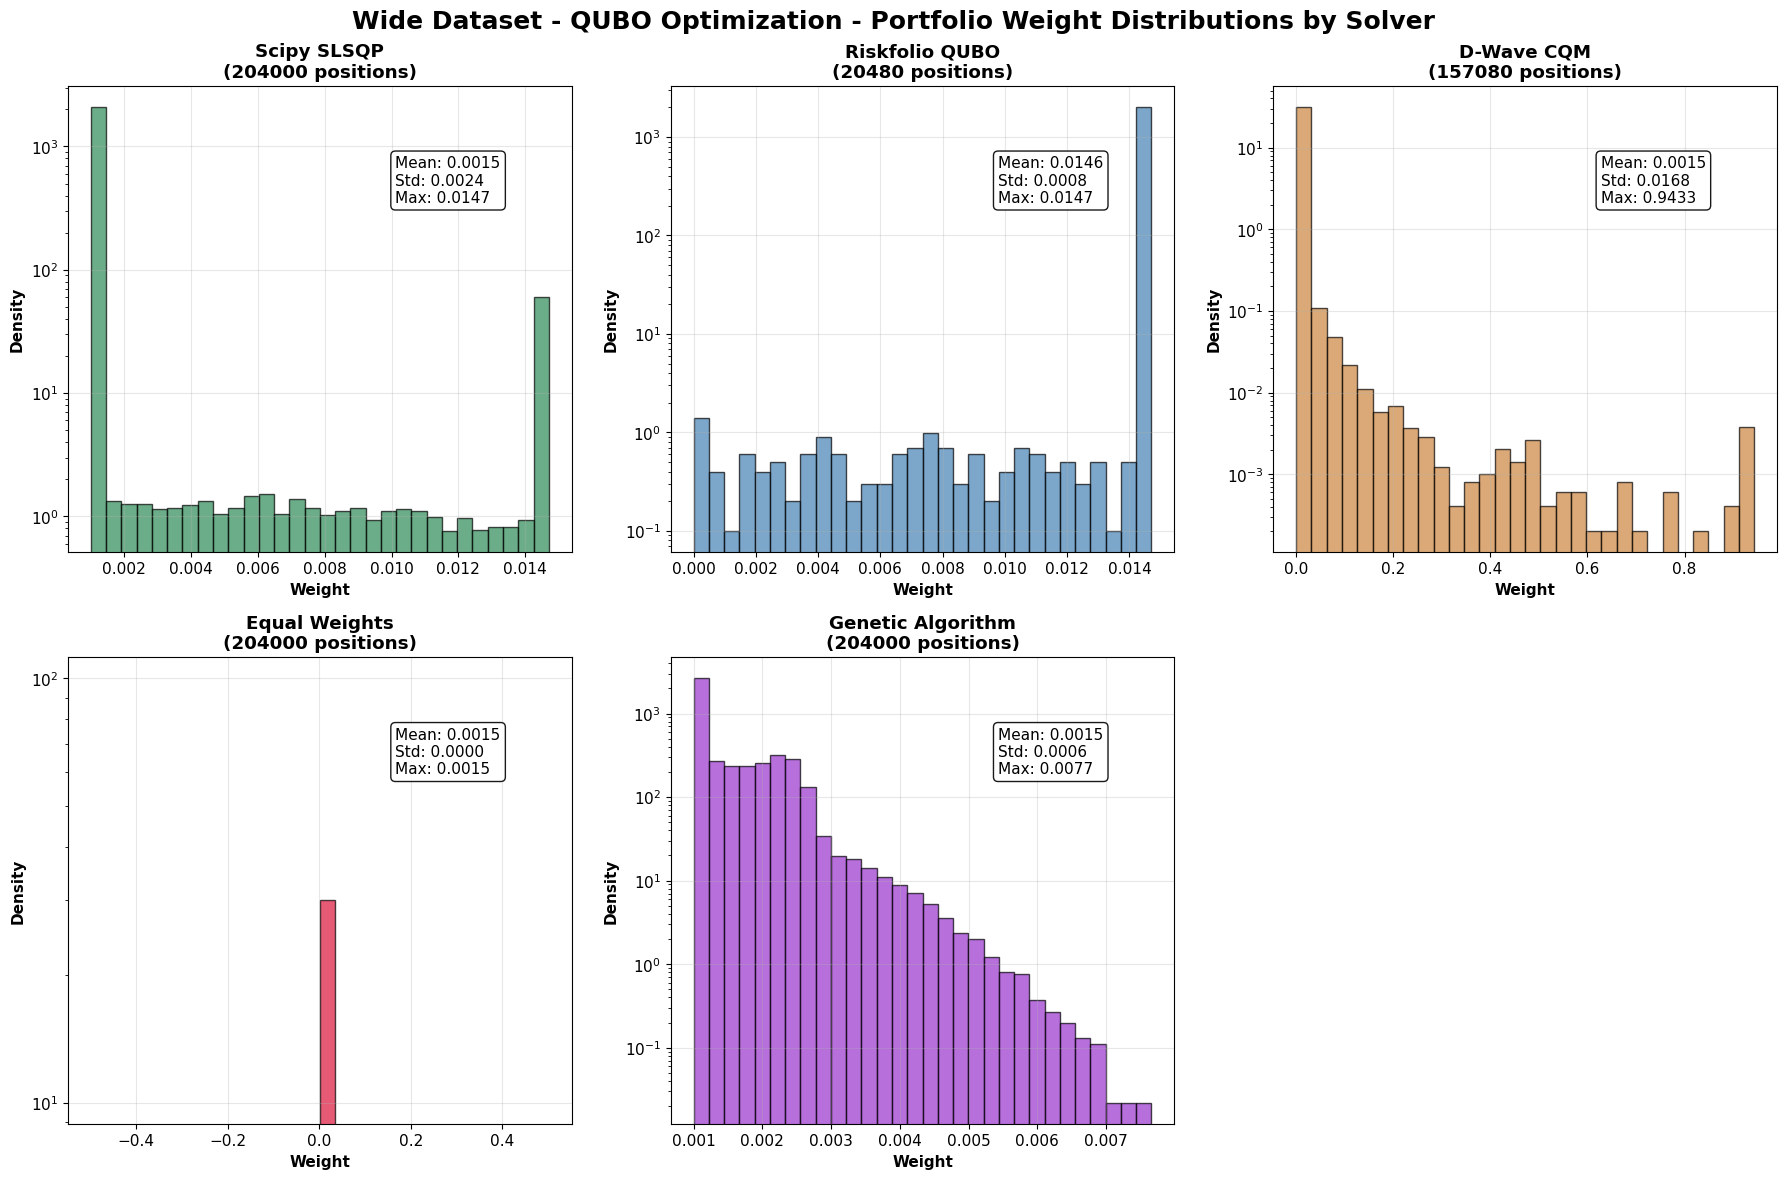


WEIGHT CONCENTRATION ANALYSIS

D-Wave CQM:
------------------------------------------------------------
  Herfindahl-Hirschman Index (HHI): 44.547803
  Effective number of positions: 0.02
  Total positions: 157080
  Concentration ratio: 6997568.8653
  Gini coefficient: 0.8841 (0=perfect equality, 1=perfect inequality)

Equal Weights:
------------------------------------------------------------
  Herfindahl-Hirschman Index (HHI): 0.441176
  Effective number of positions: 2.27
  Total positions: 204000
  Concentration ratio: 90000.0000
  Gini coefficient: -0.0000 (0=perfect equality, 1=perfect inequality)

Genetic Algorithm:
------------------------------------------------------------
  Herfindahl-Hirschman Index (HHI): 0.524806
  Effective number of positions: 1.91
  Total positions: 204000
  Concentration ratio: 107060.3368
  Gini coefficient: 0.2123 (0=perfect equality, 1=perfect inequality)

Riskfolio QUBO:
------------------------------------------------------------
  Herfindahl-Hi

In [7]:
# Comprehensive Weight Distribution Analysis for Wide Dataset
print("\n" + "=" * 100)
print("WEIGHT DISTRIBUTION ANALYSIS - WIDE DATASET")
print("=" * 100)
print("\nAnalyzing how different solvers allocate weights across the 680 available assets...")

# Run weight distribution analysis
weights_by_solver = plot_weight_distribution_histograms(
    df_wide, 
    'Wide Dataset - QUBO Optimization',
    bins=30
)

# Additional analysis: Weight concentration
print("\n" + "=" * 100)
print("WEIGHT CONCENTRATION ANALYSIS")
print("=" * 100)

for solver_name in sorted(weights_by_solver.keys()):
    weights = np.array(weights_by_solver[solver_name])
    
    print(f"\n{solver_name}:")
    print("-" * 60)
    
    # Calculate Herfindahl-Hirschman Index (HHI) - measure of concentration
    # HHI ranges from 1/n (perfectly diversified) to 1 (fully concentrated)
    hhi = np.sum(weights ** 2)
    
    # Effective number of positions
    effective_n = 1 / hhi if hhi > 0 else 0
    
    print(f"  Herfindahl-Hirschman Index (HHI): {hhi:.6f}")
    print(f"  Effective number of positions: {effective_n:.2f}")
    print(f"  Total positions: {len(weights)}")
    print(f"  Concentration ratio: {hhi * len(weights):.4f}")
    
    # Gini coefficient - measure of inequality
    sorted_weights = np.sort(weights)
    n = len(sorted_weights)
    cumsum = np.cumsum(sorted_weights)
    gini = (2 * np.sum((np.arange(1, n+1)) * sorted_weights)) / (n * np.sum(sorted_weights)) - (n + 1) / n
    print(f"  Gini coefficient: {gini:.4f} (0=perfect equality, 1=perfect inequality)")